# Lisabeta SEOBNRv5HMROM dense FTI range scan

This notebook follows the same `lisabeta` FTI system used in your bias/CV notebook, but now the FTI parameter is varied over a dense almost-continuous range.

So instead of a small set of values, this notebook uses

```python
fti_values = np.linspace(fti_min, fti_max, N_fti)
```

and plots the resulting waveforms with a continuous colorbar, similar to your pSEOBNRv5HM ringdown-modification figure.

The FTI parameter is activated through `lisabeta`, not through direct `lalsimulation` calls:

```python
params[fti_param] = fti_value

waveform_params_local["tgr_params"] = {
    "FTI": {
        "fti_params": [fti_param],
        "Mchirp_inj": params_complete["Mchirp"],
        "dxi0v_inj": 0.0,
    }
}
```

and the waveform is generated using:

```python
lisa.GenerateLISATDIFreqseries_SMBH(params, freq_grid, **waveform_params)
```


## 1. Imports

In [1]:
%matplotlib inline

import os
import copy
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import cm, colors

# Same lisabeta-side imports used in your working notebook.
import lisabeta
import lisabeta.tgr.fti as fti
import lisabeta.pyconstants as pyconstants
import lisabeta.tools.pytools as pytools
import lisabeta.tools.pyspline as pyspline
import lisabeta.tools.pyoverlap as pyoverlap
import lisabeta.lisa.pyresponse as pyresponse
import lisabeta.lisa.snrtools as snrtools
import lisabeta.lisa.pyLISAnoise as pyLISAnoise
import lisabeta.lisa.lisatools as lisatools
import lisabeta.lisa.lisa as lisa
import lisabeta.lisa.lisa_fisher as lisa_fisher
import lisabeta.utils.plotutils as plotutils
import lisabeta.inference.inference as inference

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.linestyle": ":",
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
})

outdir = Path("lisabeta_seobnrv5hmrom_fd_fti_dense_range_outputs")
outdir.mkdir(parents=True, exist_ok=True)

print("lisabeta imported from:", lisabeta.__file__)
print("Saving outputs to:", outdir.resolve())

/pbs/home/a/amahdi/lisabeta/src/lisabeta/waveforms/bbh/lalsim_wrap.py:10: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lisabeta imported from: /pbs/home/a/amahdi/lisabeta/src/lisabeta/__init__.py
Saving outputs to: /pbs/home/a/amahdi/Simulating deviations/lisabeta_seobnrv5hmrom_fd_fti_dense_range_outputs


## 2. Source parameters

These are the same style of SMBH source parameters used in your notebooks.

Here `dist` is in Mpc, angles are in radians, and `M` is in solar masses.

In [2]:
params_base = {
    "M": 1.0e6,
    "q": 4.0,
    "chi1": 0.5,
    "chi2": 0.5,
    "dist": 6791.810623950696,
    "inc": np.pi / 3,
    "phi": 0.7,
    "lambda": 1.0,
    "beta": np.pi / 6,
    "psi": 1.2,
    "Deltat": 0.0,
    "Lframe": True,
}

params_complete = pytools.complete_mass_params(params_base.copy())

print("Input parameters:")
for k, v in params_base.items():
    print(f"  {k:8s} = {v}")

print("\nMass/spin parameters completed by lisabeta:")
for k in ["Mchirp", "q", "chiPN", "chim"]:
    if k in params_complete:
        print(f"  {k:8s} = {params_complete[k]}")

Input parameters:
  M        = 1000000.0
  q        = 4.0
  chi1     = 0.5
  chi2     = 0.5
  dist     = 6791.810623950696
  inc      = 1.0471975511965976
  phi      = 0.7
  lambda   = 1.0
  beta     = 0.5235987755982988
  psi      = 1.2
  Deltat   = 0.0
  Lframe   = True

Mass/spin parameters completed by lisabeta:
  Mchirp   = 333021.2829607493
  q        = 4.0


## 3. Frequency grid

Two options are provided.

1. Make a fresh uniform frequency grid.
2. Reuse a frequency grid from one of your existing `TDIAET` injection HDF5 files.

By default, the notebook makes a fresh grid.

In [3]:
USE_EXISTING_INJECTION_GRID = False

# If USE_EXISTING_INJECTION_GRID = True, set this to one of your data_*.h5 files.
existing_data_file = "/pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_scan_M1e6/M1e6/data_SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_scan_M1e6_M1e6_id_0.h5"

# Fresh-grid settings.
minf = 1.0e-5
maxf = 2.0e-1
T_obs = 3.0 * 86400.0
delta_f = 1.0 / T_obs

if USE_EXISTING_INJECTION_GRID:
    if not os.path.exists(existing_data_file):
        raise FileNotFoundError(existing_data_file)
    tdidata_ref = inference.load_data_TDIAET(existing_data_file)
    freq_grid = np.asarray(tdidata_ref["freq"], dtype=float)
    print("Using frequency grid from:", existing_data_file)
else:
    freq_grid = np.arange(minf, maxf + 0.5 * delta_f, delta_f)
    print("Using fresh uniform frequency grid.")

print("f_min =", freq_grid[0])
print("f_max =", freq_grid[-1])
print("Nfreq =", len(freq_grid))
print("delta_f approximate =", np.median(np.diff(freq_grid)))

Using fresh uniform frequency grid.
f_min = 1e-05
f_max = 0.19999842592592598
Nfreq = 51838
delta_f approximate = 3.858024691355544e-06


## 4. Lisabeta waveform settings

Important point: in `lisabeta`, the approximant string used in your working notebook is:

```python
"SEOBNRv5HMROM"
```

So we keep this string here. We do not replace it by the raw LAL name.

In [4]:
waveform_params_base = {
    "minf": float(np.min(freq_grid)),
    "maxf": float(np.max(freq_grid)),
    "t0": 0.0,
    "timetomerger_max": 1.0,
    "fend": None,
    "tmin": None,
    "tmax": None,
    "phiref": 0.0,
    "fref_for_phiref": 0.0,
    "tref": 0.0,
    "fref_for_tref": 0.0,
    "force_phiref_fref": True,
    "toffset": 0.0,

    # Same higher modes used in your pSEOB ratio/phase wrapper and recovery notebook.
    "modes": [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)],

    "TDI": "TDIAET",
    "acc": 0.0001,
    "order_fresnel_stencil": 0,

    # This is the lisabeta approximant name used in your notebook.
    "approximant": "SEOBNRv5HMROM",

    "LISAconst": "Proposal",
    "responseapprox": "full",
    "frozenLISA": False,
    "TDIrescaled": True,
    "LISAnoise": {
        "InstrumentalNoise": "SciRDv1",
        "WDbackground": True,
        "WDduration": 4.0,
        "lowf_add_pm_noise_f0": 0.0,
        "lowf_add_pm_noise_alpha": 2.0,
    },
}

print("Recovery/generation approximant:", waveform_params_base["approximant"])
print("Modes:", waveform_params_base["modes"])
print("TDI:", waveform_params_base["TDI"])

Recovery/generation approximant: SEOBNRv5HMROM
Modes: [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
TDI: TDIAET


## 5. Dense FTI range

This is the main change.

The scan is now dense and almost continuous:

```python
fti_values = np.linspace(fti_min, fti_max, N_fti)
```

For a plot like your ringdown figure, a good first choice is:

```python
fti_min = -0.1
fti_max =  0.1
N_fti = 101
```

If it is too slow, test with `N_fti = 21` first. For a smoother presentation-quality figure, try `N_fti = 201`.


In [5]:
ALL_FTI_PARAMS = [
    "fti_dchiMinus2v",
    "fti_dchi0v",
    "fti_dchi1v",
    "fti_dchi2v",
    "fti_dchi3v",
    "fti_dchi4v",
    "fti_dchi5lv",
    "fti_dchi6v",
    "fti_dchi6lv",
    "fti_dchi7v",
    "fti_dkappa_S",
    "fti_dxi0v",
]

# Main active FTI parameter.
# If by "2nd FTI parameter" you mean the second item of ALL_FTI_PARAMS, use:
# fti_param = "fti_dchi0v"
fti_param = "fti_dchi2v"

# Dense almost-continuous range, like your ringdown-deviation figure.
fti_min = -0.1
fti_max =  0.1
N_fti = 101

fti_values = np.linspace(fti_min, fti_max, N_fti)

if fti_param not in ALL_FTI_PARAMS:
    raise ValueError(f"Unknown fti_param={fti_param}. Choose from: {ALL_FTI_PARAMS}")

# Make sure the zero-FTI baseline is included.
if not np.any(np.isclose(fti_values, 0.0)):
    fti_values = np.sort(np.unique(np.append(fti_values, 0.0)))

baseline_value = 0.0

print("Active FTI parameter:", fti_param)
print("Range:", fti_values[0], "to", fti_values[-1])
print("Number of values:", len(fti_values))
print("Contains zero:", np.any(np.isclose(fti_values, 0.0)))


Active FTI parameter: fti_dchi2v
Range: -0.1 to 0.1
Number of values: 101
Contains zero: True


## 6. Helper functions using the same lisabeta FTI mechanism

This is the essential part copied from the logic of your working notebook:

- remove all FTI keys first
- add only the active FTI parameter
- set `waveform_params["tgr_params"]["FTI"]["fti_params"] = [fti_param]`
- generate the TDI frequency series with `lisa.GenerateLISATDIFreqseries_SMBH`

In [6]:
def prepare_params_and_waveform_params(params_input, fti_param, fti_value):
    # Prepare params and waveform_params following the lisabeta FTI system.
    params = params_input.copy()

    # Important: remove every FTI key first.
    # Your working notebook notes that lisabeta checks key presence, not only value.
    for p in ALL_FTI_PARAMS:
        params.pop(p, None)

    # Add only the active FTI parameter.
    params[fti_param] = float(fti_value)

    # Complete Mchirp, chiPN, chim, etc.
    params_complete = pytools.complete_mass_params(params.copy())

    waveform_params_local = copy.deepcopy(waveform_params_base)
    waveform_params_local.pop("tgr_params", None)

    waveform_params_local["tgr_params"] = {
        "FTI": {
            "fti_params": [fti_param],
            "Mchirp_inj": params_complete["Mchirp"],
            "dxi0v_inj": 0.0,
        }
    }

    return params_complete, waveform_params_local


def sum_lisabeta_tdi_modes(tdifreqseries, freq_grid):
    # Sum lisabeta mode-by-mode TDI frequency series into TDIA, TDIE, TDIT.
    tdi = {
        "freq": np.asarray(freq_grid).copy(),
        "TDIA": np.zeros(len(freq_grid), dtype=complex),
        "TDIE": np.zeros(len(freq_grid), dtype=complex),
        "TDIT": np.zeros(len(freq_grid), dtype=complex),
    }

    for lm in tdifreqseries["modes"]:
        tdi["TDIA"] += np.asarray(tdifreqseries[lm]["chan1"], dtype=complex)
        tdi["TDIE"] += np.asarray(tdifreqseries[lm]["chan2"], dtype=complex)
        tdi["TDIT"] += np.asarray(tdifreqseries[lm]["chan3"], dtype=complex)

    return tdi


def generate_lisabeta_fti_tdi(params_input, freq_grid, fti_param, fti_value):
    # Generate a lisabeta SEOBNRv5HMROM TDI FD waveform for one FTI value.
    params, waveform_params = prepare_params_and_waveform_params(
        params_input=params_input,
        fti_param=fti_param,
        fti_value=fti_value,
    )

    print(f"Generating {fti_param} = {fti_value:+.6g}")
    print("  Active lisabeta FTI params:", waveform_params["tgr_params"]["FTI"]["fti_params"])

    tdifreqseries = lisa.GenerateLISATDIFreqseries_SMBH(
        params,
        freq_grid,
        **waveform_params,
    )

    tdi = sum_lisabeta_tdi_modes(tdifreqseries, freq_grid)

    # Do not keep the full mode-by-mode tdifreqseries for dense scans, because it is memory-heavy.
    return {
        "params": params,
        "waveform_params": waveform_params,
        "tdi": tdi,
    }


def safe_value_label(x):
    return str(x).replace("-", "m").replace("+", "p").replace(".", "p")


def valid_channel_mask(freq, h, threshold_fraction=1e-12):
    amp = np.abs(h)
    if np.nanmax(amp) == 0:
        return np.zeros_like(freq, dtype=bool)
    threshold = threshold_fraction * np.nanmax(amp)
    return (
        np.isfinite(freq)
        & np.isfinite(amp)
        & (freq > 0.0)
        & (amp > threshold)
    )

## 7. Generate dense scan

This cell can take time for `N_fti = 101`.

For a quick first test, set:

```python
N_fti = 21
```

in the previous cell.

In [7]:
scan_results = {}

for i, value in enumerate(fti_values):
    if (i % max(1, len(fti_values)//10) == 0) or np.isclose(value, 0.0):
        print(f"[{i+1:4d}/{len(fti_values)}] {fti_param} = {value:+.6g}")

    result = generate_lisabeta_fti_tdi(
        params_input=params_base,
        freq_grid=freq_grid,
        fti_param=fti_param,
        fti_value=value,
    )
    scan_results[float(value)] = result

# Find the exact or nearest zero baseline.
baseline_key = min(scan_results.keys(), key=lambda x: abs(x - baseline_value))
if abs(baseline_key) > 1e-12:
    raise RuntimeError("No zero baseline found. Add 0.0 to fti_values.")

tdi_gr = scan_results[baseline_key]["tdi"]

print("\nFinished dense scan.")
print("Baseline key:", baseline_key)
for chan in ["TDIA", "TDIE", "TDIT"]:
    print(chan, "max amplitude baseline =", np.max(np.abs(tdi_gr[chan])))


[   1/101] fti_dchi2v = -0.1
Generating fti_dchi2v = -0.1
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = -0.098
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = -0.096
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = -0.094
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = -0.092
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = -0.09
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = -0.088
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = -0.086
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = -0.084
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = -0.082
  Active lisabeta FTI params: ['fti_dchi2v']
[  11/101] fti_dchi2v = -0.08
Generating fti_dchi2v = -0.08
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = -0.078
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = -0.076
  

## 8. Save dense waveforms

This saves the dense scan to an HDF5 file.

In [8]:
h5_path = outdir / f"lisabeta_{waveform_params_base['approximant']}_{fti_param}_dense_range_TDIAET.h5"

with h5py.File(h5_path, "w") as hf:
    hf.attrs["approximant"] = waveform_params_base["approximant"]
    hf.attrs["fti_param"] = fti_param
    hf.attrs["fti_min"] = float(fti_values[0])
    hf.attrs["fti_max"] = float(fti_values[-1])
    hf.attrs["N_fti"] = int(len(fti_values))
    hf.attrs["modes"] = str(waveform_params_base["modes"])
    hf.create_dataset("freq", data=freq_grid)
    hf.create_dataset("fti_values", data=fti_values)

    # Save source params as attributes.
    for k, v in params_base.items():
        try:
            hf.attrs[k] = v
        except TypeError:
            hf.attrs[k] = str(v)

    for value, result in scan_results.items():
        grp = hf.create_group(f"value_{safe_value_label(value)}")
        grp.attrs["fti_value"] = float(value)
        tdi = result["tdi"]
        for chan in ["TDIA", "TDIE", "TDIT"]:
            grp.create_dataset(chan, data=tdi[chan])

print("Saved:", h5_path)


Saved: lisabeta_seobnrv5hmrom_fd_fti_dense_range_outputs/lisabeta_SEOBNRv5HMROM_fti_dchi2v_dense_range_TDIAET.h5


## 9. Dense amplitude plots with colorbar

This gives a plot style close to your ringdown-deviation figure: many curves, colored by the FTI value, with a colorbar.

The black curve is the zero-FTI baseline.

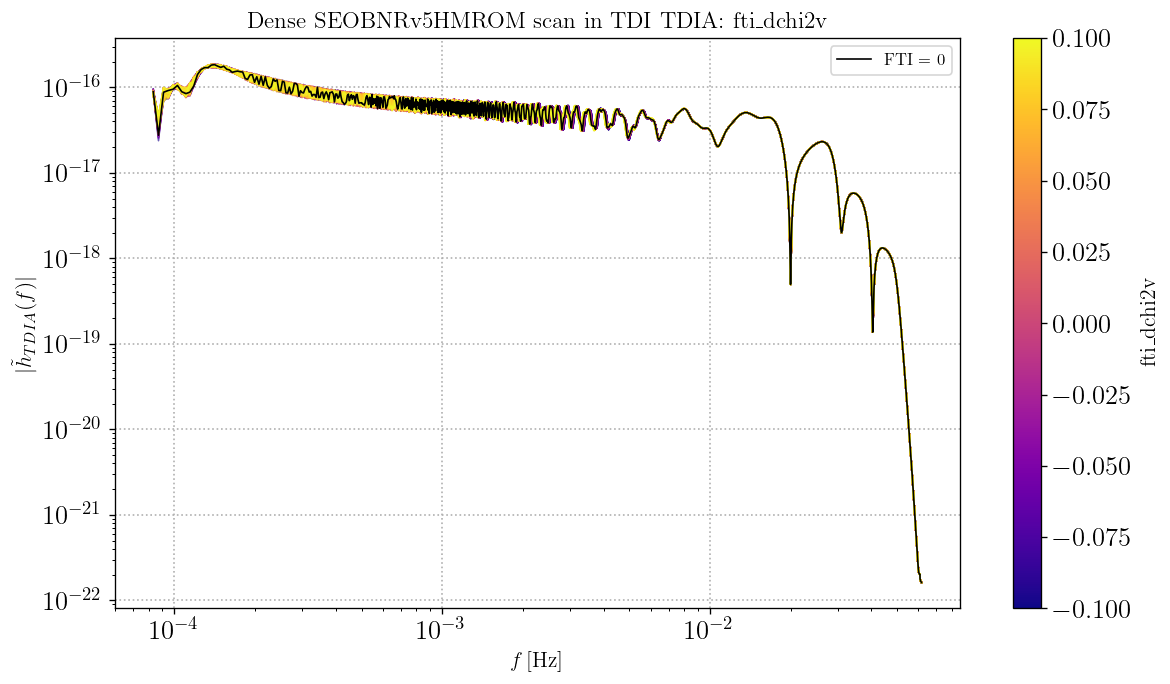

Saved: lisabeta_seobnrv5hmrom_fd_fti_dense_range_outputs/plots/dense_amplitude_colorbar_TDIA_fti_dchi2v.png


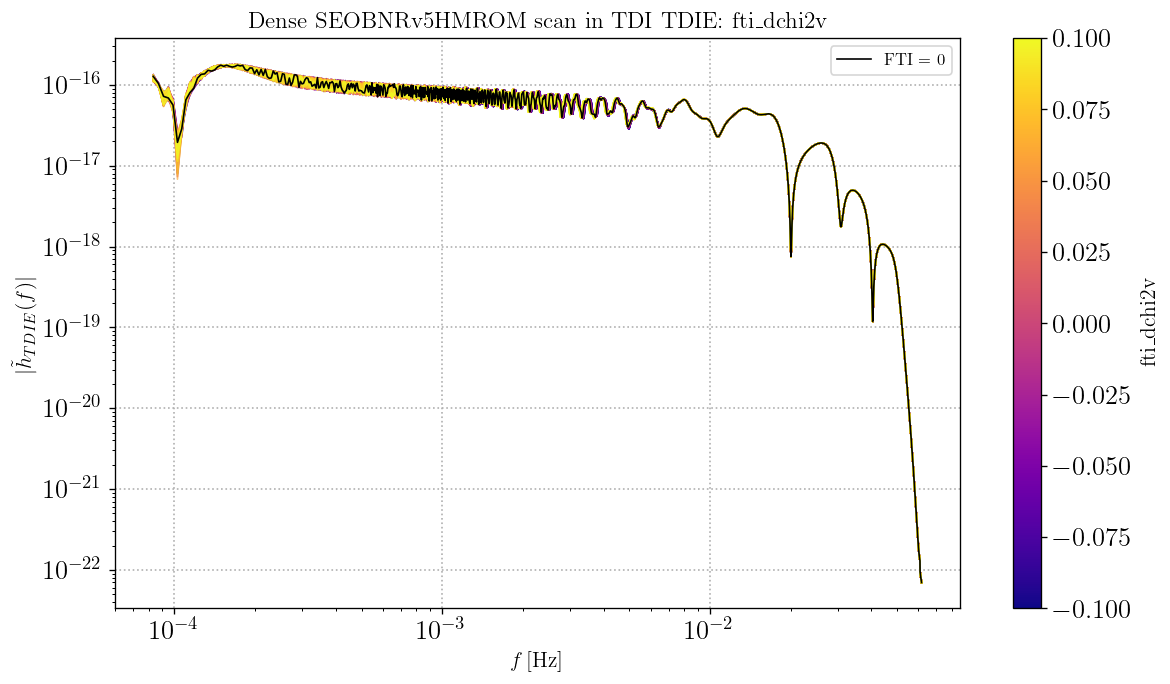

Saved: lisabeta_seobnrv5hmrom_fd_fti_dense_range_outputs/plots/dense_amplitude_colorbar_TDIE_fti_dchi2v.png


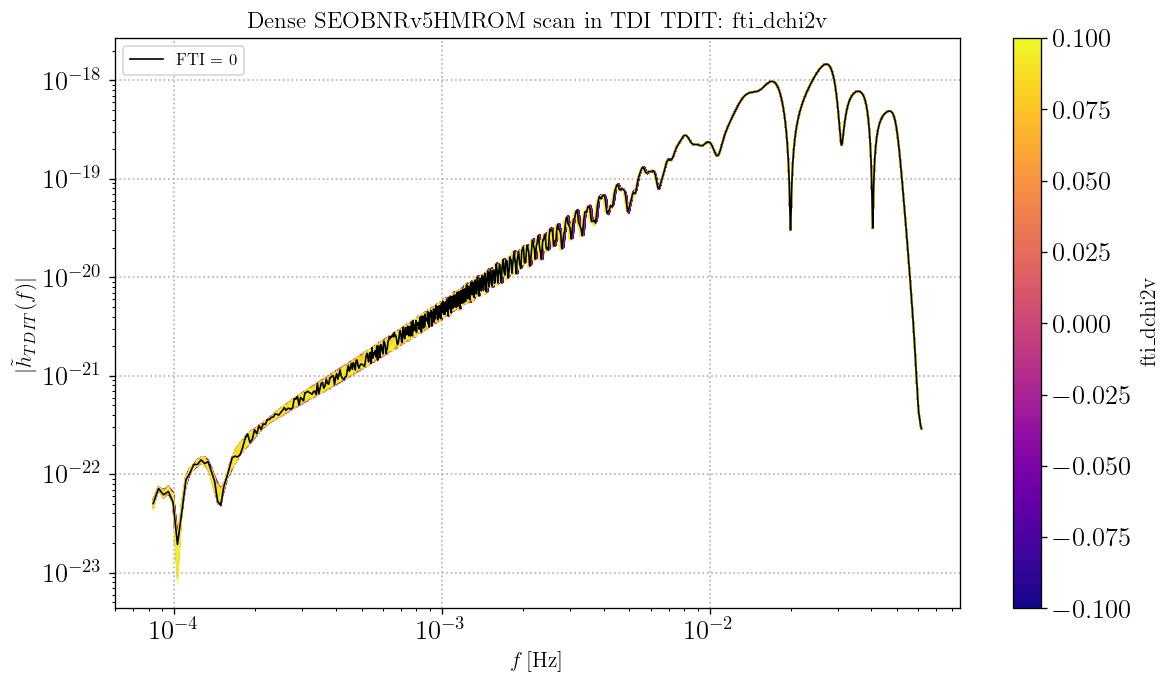

Saved: lisabeta_seobnrv5hmrom_fd_fti_dense_range_outputs/plots/dense_amplitude_colorbar_TDIT_fti_dchi2v.png


In [14]:
plot_dir = outdir / "plots"
plot_dir.mkdir(exist_ok=True)

cmap = cm.plasma
norm = colors.Normalize(vmin=float(np.min(fti_values)), vmax=float(np.max(fti_values)))

for chan in ["TDIA", "TDIE", "TDIT"]:
    fig, ax = plt.subplots(figsize=(10, 5.8))

    # Dense colored FTI curves.
    for value in fti_values:
        h = scan_results[float(value)]["tdi"][chan]
        mask = valid_channel_mask(freq_grid, h, threshold_fraction=1e-12)
        ax.loglog(
            freq_grid[mask],
            np.abs(h[mask]),
            color=cmap(norm(value)),
            lw=1.0,
            alpha=0.65,
        )

    # Baseline in black.
    h0 = tdi_gr[chan]
    mask0 = valid_channel_mask(freq_grid, h0, threshold_fraction=1e-12)
    ax.loglog(
        freq_grid[mask0],
        np.abs(h0[mask0]),
        color="black",
        lw=1.0,
        label="FTI = 0",
        zorder=10,
    )

    ax.set_xlabel(r"$f\,[\mathrm{Hz}]$")
    ax.set_ylabel(rf"$|\tilde h_{{{chan}}}(f)|$")
    ax.set_title(rf"Dense {waveform_params_base['approximant']} scan in TDI {chan}: {fti_param}")
    ax.legend(loc="best")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(fti_param)

    fig.tight_layout()
    fig_path = plot_dir / f"dense_amplitude_colorbar_{chan}_{fti_param}.png"
    fig.savefig(fig_path, dpi=250)
    plt.show()
    print("Saved:", fig_path)


## 10. Dense phase-difference plots with colorbar

This is usually more informative for FTI phase parameters.

For each curve:

```python
Delta phase = unwrap(angle(h_FTI / h_0))
```

where `h_0` is the zero-FTI waveform.

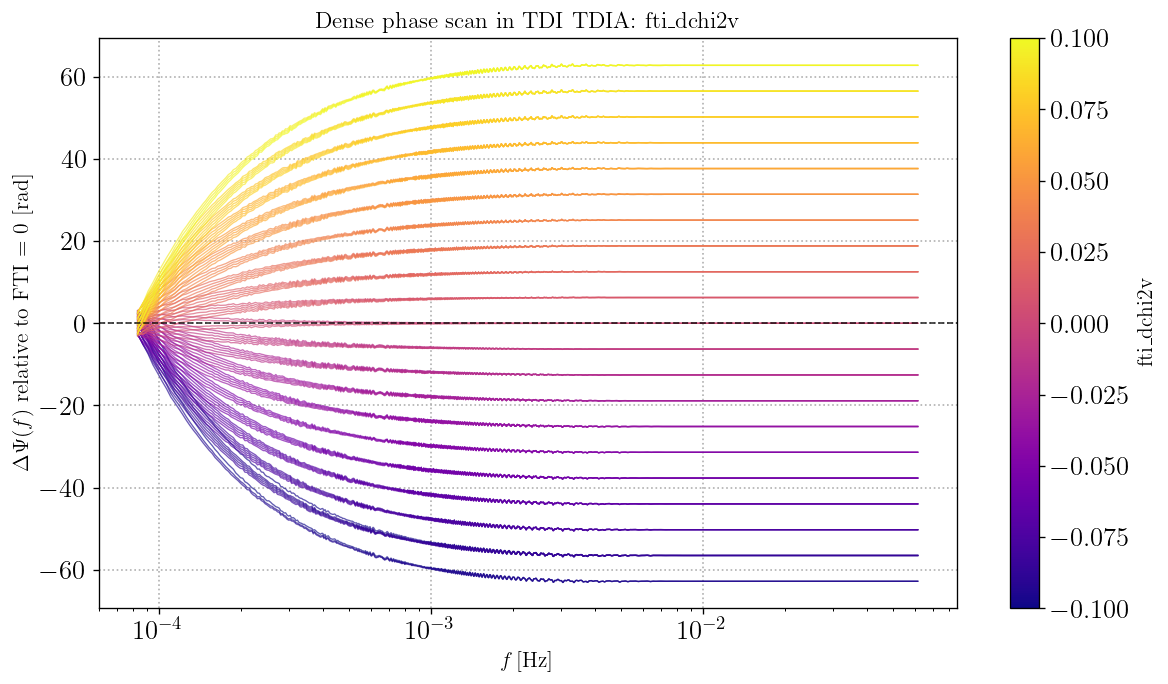

Saved: lisabeta_seobnrv5hmrom_fd_fti_dense_range_outputs/plots/dense_phase_difference_colorbar_TDIA_fti_dchi2v.png


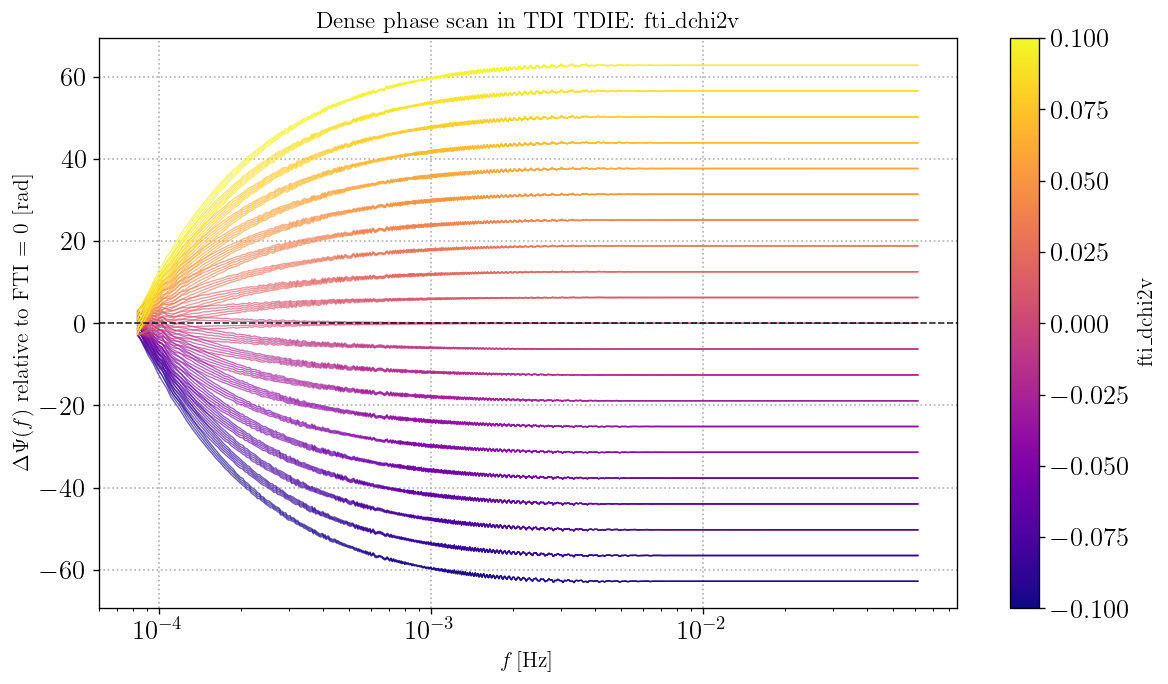

Saved: lisabeta_seobnrv5hmrom_fd_fti_dense_range_outputs/plots/dense_phase_difference_colorbar_TDIE_fti_dchi2v.png


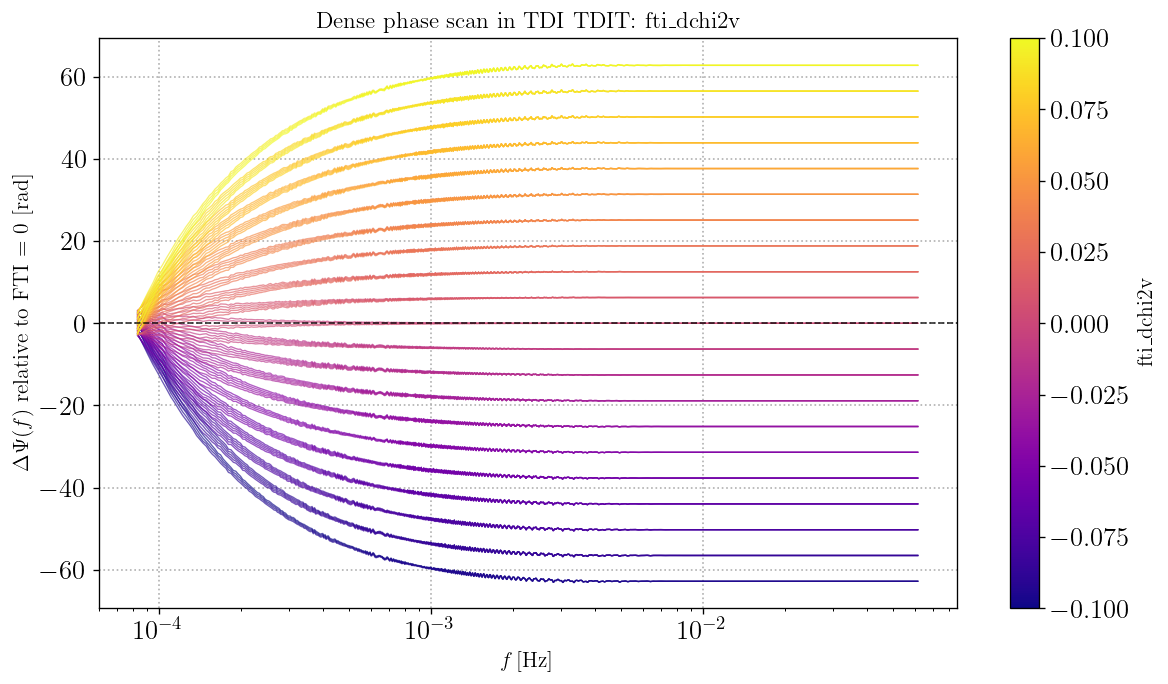

Saved: lisabeta_seobnrv5hmrom_fd_fti_dense_range_outputs/plots/dense_phase_difference_colorbar_TDIT_fti_dchi2v.png


In [10]:
for chan in ["TDIA", "TDIE", "TDIT"]:
    fig, ax = plt.subplots(figsize=(10, 5.8))

    h0 = tdi_gr[chan]
    mask0 = valid_channel_mask(freq_grid, h0, threshold_fraction=1e-10)

    for value in fti_values:
        if np.isclose(value, baseline_key):
            continue

        h = scan_results[float(value)]["tdi"][chan]
        mask = mask0 & valid_channel_mask(freq_grid, h, threshold_fraction=1e-10)

        if np.sum(mask) == 0:
            continue

        dphase = np.unwrap(np.angle(h[mask] / h0[mask]))

        ax.plot(
            freq_grid[mask],
            dphase,
            color=cmap(norm(value)),
            lw=0.8,
            alpha=0.65,
        )

    ax.axhline(0.0, color="black", lw=1.0, ls="--", alpha=0.8)

    ax.set_xscale("log")
    ax.set_xlabel(r"$f\,[\mathrm{Hz}]$")
    ax.set_ylabel(r"$\Delta \Psi(f)$ relative to FTI = 0 [rad]")
    ax.set_title(rf"Dense phase scan in TDI {chan}: {fti_param}")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(fti_param)

    fig.tight_layout()
    fig_path = plot_dir / f"dense_phase_difference_colorbar_{chan}_{fti_param}.png"
    fig.savefig(fig_path, dpi=250)
    plt.show()
    print("Saved:", fig_path)


## 11. Dense relative-amplitude plots with colorbar

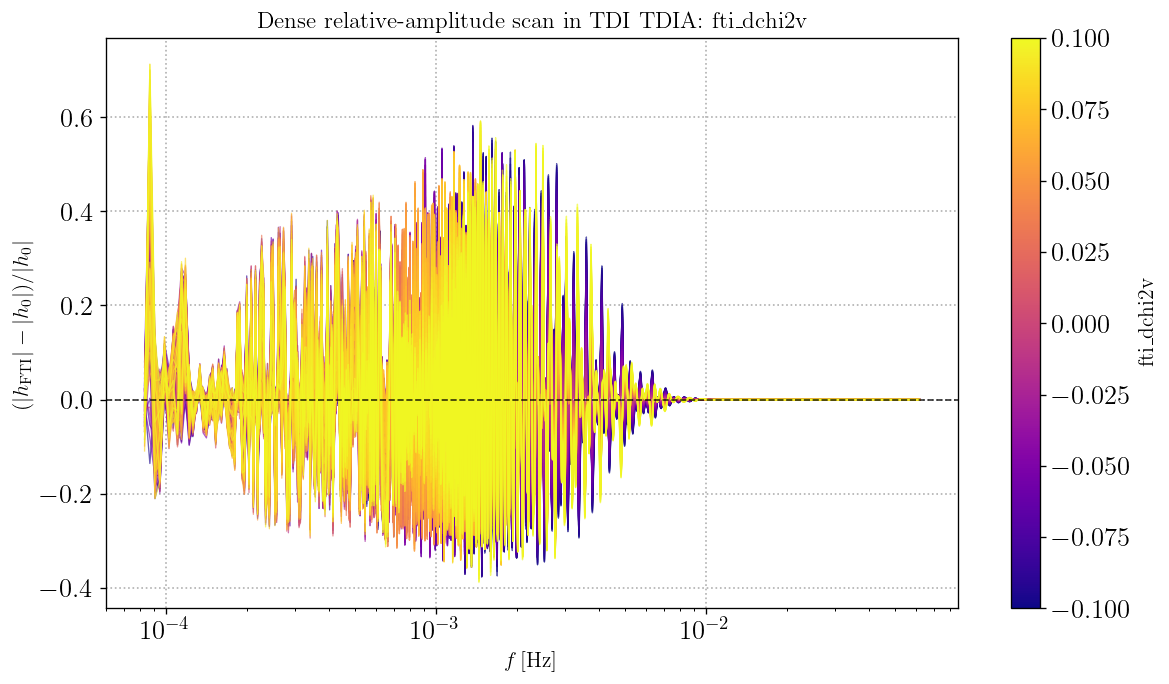

Saved: lisabeta_seobnrv5hmrom_fd_fti_dense_range_outputs/plots/dense_relative_amplitude_colorbar_TDIA_fti_dchi2v.png


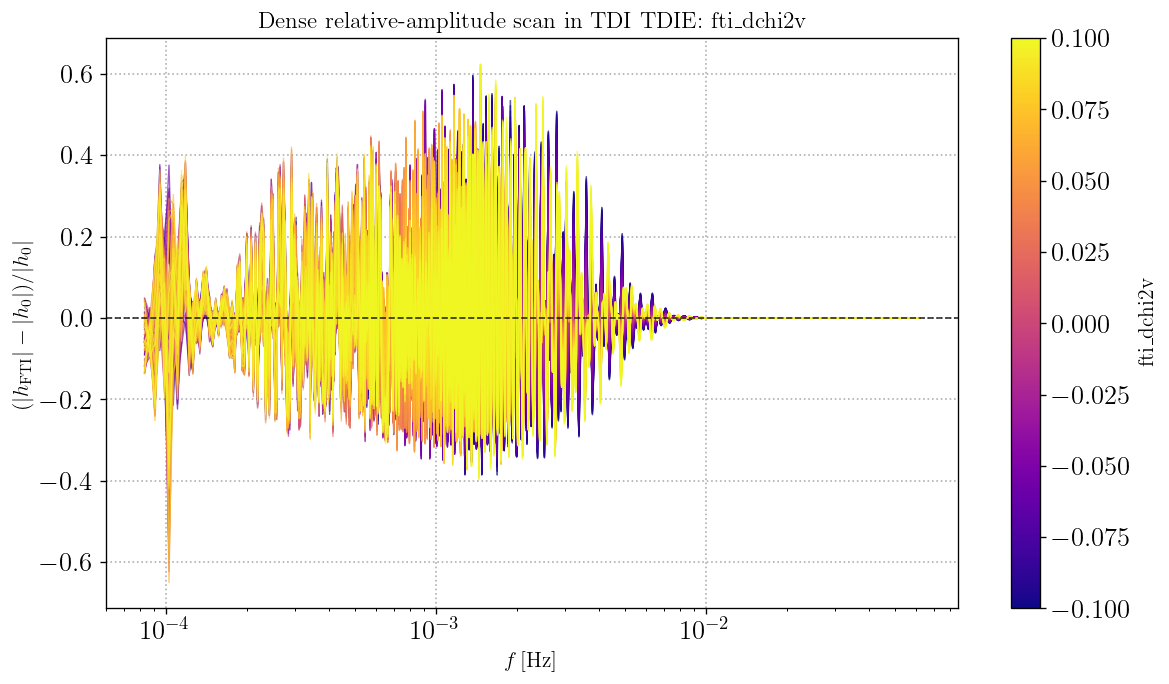

Saved: lisabeta_seobnrv5hmrom_fd_fti_dense_range_outputs/plots/dense_relative_amplitude_colorbar_TDIE_fti_dchi2v.png


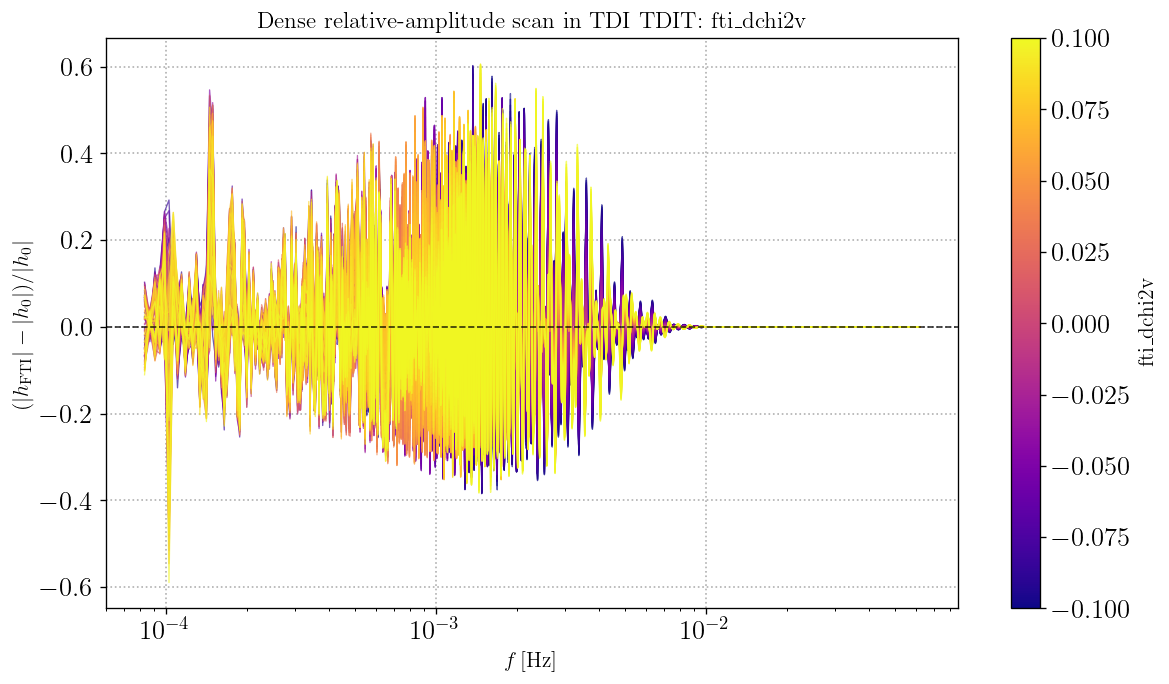

Saved: lisabeta_seobnrv5hmrom_fd_fti_dense_range_outputs/plots/dense_relative_amplitude_colorbar_TDIT_fti_dchi2v.png


In [11]:
for chan in ["TDIA", "TDIE", "TDIT"]:
    fig, ax = plt.subplots(figsize=(10, 5.8))

    h0 = tdi_gr[chan]
    mask0 = valid_channel_mask(freq_grid, h0, threshold_fraction=1e-10)

    for value in fti_values:
        if np.isclose(value, baseline_key):
            continue

        h = scan_results[float(value)]["tdi"][chan]
        mask = mask0 & valid_channel_mask(freq_grid, h, threshold_fraction=1e-10)

        if np.sum(mask) == 0:
            continue

        rel_amp = (np.abs(h[mask]) - np.abs(h0[mask])) / np.abs(h0[mask])

        ax.plot(
            freq_grid[mask],
            rel_amp,
            color=cmap(norm(value)),
            lw=0.8,
            alpha=0.65,
        )

    ax.axhline(0.0, color="black", lw=1.0, ls="--", alpha=0.8)

    ax.set_xscale("log")
    ax.set_xlabel(r"$f\,[\mathrm{Hz}]$")
    ax.set_ylabel(r"$(|h_{\rm FTI}|-|h_0|)/|h_0|$")
    ax.set_title(rf"Dense relative-amplitude scan in TDI {chan}: {fti_param}")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(fti_param)

    fig.tight_layout()
    fig_path = plot_dir / f"dense_relative_amplitude_colorbar_{chan}_{fti_param}.png"
    fig.savefig(fig_path, dpi=250)
    plt.show()
    print("Saved:", fig_path)


## 12. Optional: FD real-part plot with colorbar

This is closer in visual spirit to your time-domain ringdown plot, except the x-axis is frequency.

In [12]:
for chan in ["TDIA", "TDIE", "TDIT"]:
    fig, ax = plt.subplots(figsize=(10, 5.8))

    h0 = tdi_gr[chan]
    mask0 = valid_channel_mask(freq_grid, h0, threshold_fraction=1e-10)

    # Normalize by maximum baseline amplitude so the curves are readable.
    norm_amp = np.max(np.abs(h0[mask0]))
    if norm_amp == 0:
        norm_amp = 1.0

    for value in fti_values:
        h = scan_results[float(value)]["tdi"][chan]
        mask = mask0 & valid_channel_mask(freq_grid, h, threshold_fraction=1e-10)

        if np.sum(mask) == 0:
            continue

        ax.plot(
            freq_grid[mask],
            np.real(h[mask]) / norm_amp,
            color=cmap(norm(value)),
            lw=0.8,
            alpha=0.65,
        )

    ax.plot(
        freq_grid[mask0],
        np.real(h0[mask0]) / norm_amp,
        color="black",
        lw=2.0,
        label="FTI = 0",
        zorder=10,
    )

    ax.set_xscale("log")
    ax.set_xlabel(r"$f\,[\mathrm{Hz}]$")
    ax.set_ylabel(rf"$\mathrm{{Re}}(\tilde h_{{{chan}}})/\max|\tilde h_{{{chan}},0}|$")
    ax.set_title(rf"Dense FD real-part scan in TDI {chan}: {fti_param}")
    ax.legend(loc="best")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(fti_param)

    fig.tight_layout()
    fig_path = plot_dir / f"dense_real_part_colorbar_{chan}_{fti_param}.png"
    fig.savefig(fig_path, dpi=250)
    plt.show()
    print("Saved:", fig_path)


SyntaxError: f-string: single '}' is not allowed (685027168.py, line 38)

## 13. Summary table for the dense range

In [ ]:
summary_rows = []

for value, result in scan_results.items():
    row = {
        "approximant": waveform_params_base["approximant"],
        "fti_param": fti_param,
        "fti_value": value,
    }

    for chan in ["TDIA", "TDIE", "TDIT"]:
        h = result["tdi"][chan]
        h0 = tdi_gr[chan]
        mask = valid_channel_mask(freq_grid, h0, threshold_fraction=1e-10) & valid_channel_mask(freq_grid, h, threshold_fraction=1e-10)

        row[f"{chan}_max_abs"] = float(np.nanmax(np.abs(h)))
        row[f"{chan}_nonzero_bins"] = int(np.sum(mask))

        if np.isclose(value, baseline_value) or np.sum(mask) == 0:
            row[f"{chan}_max_abs_phase_diff_rad"] = 0.0
            row[f"{chan}_rms_phase_diff_rad"] = 0.0
            row[f"{chan}_max_abs_rel_amp_diff"] = 0.0
            row[f"{chan}_rms_rel_amp_diff"] = 0.0
        else:
            dphase = np.unwrap(np.angle(h[mask] / h0[mask]))
            rel_amp = (np.abs(h[mask]) - np.abs(h0[mask])) / np.abs(h0[mask])

            row[f"{chan}_max_abs_phase_diff_rad"] = float(np.nanmax(np.abs(dphase)))
            row[f"{chan}_rms_phase_diff_rad"] = float(np.sqrt(np.nanmean(dphase**2)))
            row[f"{chan}_max_abs_rel_amp_diff"] = float(np.nanmax(np.abs(rel_amp)))
            row[f"{chan}_rms_rel_amp_diff"] = float(np.sqrt(np.nanmean(rel_amp**2)))

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_csv = outdir / f"summary_{waveform_params_base['approximant']}_{fti_param}_dense_range.csv"
summary_df.to_csv(summary_csv, index=False)

display(summary_df)
print("Saved:", summary_csv)

## 14. Optional: scan several FTI parameters

This is commented out by default. It repeats the same value scan for multiple active FTI parameters.

In [ ]:
# FTI_PARAMS_TO_SCAN = [
#     "fti_dchiMinus2v",
#     "fti_dchi0v",
#     "fti_dchi1v",
#     "fti_dchi2v",
#     "fti_dchi3v",
#     "fti_dchi4v",
#     "fti_dchi5lv",
#     "fti_dchi6v",
#     "fti_dchi6lv",
#     "fti_dchi7v",
#     "fti_dkappa_S",
#     "fti_dxi0v",
# ]
#
# all_scan_summaries = []
#
# for par in FTI_PARAMS_TO_SCAN:
#     print("\n" + "=" * 90)
#     print("Scanning active FTI parameter:", par)
#     print("=" * 90)
#
#     for value in fti_values:
#         result = generate_lisabeta_fti_tdi(
#             params_input=params_base,
#             freq_grid=freq_grid,
#             fti_param=par,
#             fti_value=value,
#         )
#
#         for chan in ["TDIA", "TDIE", "TDIT"]:
#             all_scan_summaries.append({
#                 "fti_param": par,
#                 "fti_value": float(value),
#                 "channel": chan,
#                 "max_abs": float(np.nanmax(np.abs(result["tdi"][chan]))),
#             })
#
# all_scan_df = pd.DataFrame(all_scan_summaries)
# all_scan_csv = outdir / "summary_all_active_fti_parameters_value_scan.csv"
# all_scan_df.to_csv(all_scan_csv, index=False)
# display(all_scan_df)
# print("Saved:", all_scan_csv)

## 15. Notes

This notebook intentionally does not call:

```python
lalsimulation.SimInspiralChooseFDWaveform
```

because your working setup applies the FTI deformation through `lisabeta`'s waveform parameter system.

The main dense-range controls are:

```python
fti_param = "fti_dchi2v"
fti_min = -0.1
fti_max =  0.1
N_fti = 101
```

For a fast test, use `N_fti = 21`. For a smoother final figure, use `N_fti = 201`.
